# RainforcementLearning - Pekistirmeli Ogrenim

Action - Reward - next_state

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# pip install gym

In [3]:
# pip install gymnasium

In [4]:
# pip install "gymnasium[toy-text]"

In [5]:
# pip install pygame

In [6]:
import matplotlib.pyplot as plt

In [7]:
import gymnasium as gym

In [8]:
env=gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')

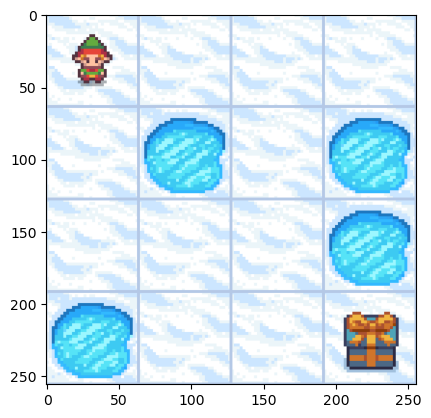

In [9]:
state=env.reset()
img=env.render()
plt.imshow(img)

In [10]:
action=env.action_space.sample()

In [11]:
next_state,reward,terminated,truncated,info = env.step(action)

In [12]:
print(next_state,reward,terminated,truncated,info)

0 0 False False {'prob': 1.0}


In [20]:
import numpy as np
import gymnasium as gym
import pickle

env=gym.make('FrozenLake-v1', is_slippery=False,render_mode='rgb_array')
state_size=env.observation_space.n
action_size=env.action_space.n
Q_table=np.zeros((state_size,action_size))

alpha=0.1 # Learning rate
gamma=0.99 #discount factor
epsilon=1.0 #exploration rate
epsilon_decay=0.995 #
epsilon_min=0.01 #
episodes=20000 #20000 bin defa oynayacak

for episode in range(episodes):
    state=env.reset()[0]
    done=False

    while not done:
        if np.random.rand()<epsilon:
            action=env.action_space.sample()
        else:
            action=np.argmax(Q_table[state])
        next_state,reward,terminated,truncated,info=env.step(action)
        Q_table[state,action]+=alpha*(reward+gamma*np.max(Q_table[next_state])-Q_table[state,action])

        state=next_state
        done= terminated or truncated

    epsilon=max(epsilon*epsilon_decay,epsilon_min)

with open('qtable_fl1.pkl','wb') as f:
    pickle.dump(Q_table,f)
print('Training completed and model saved')
env.close()

Training completed and model saved


In [21]:
np.save('frozenlake.npy',Q_table)

In [23]:
print(Q_table)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [16]:
import seaborn as sns

<Axes: >

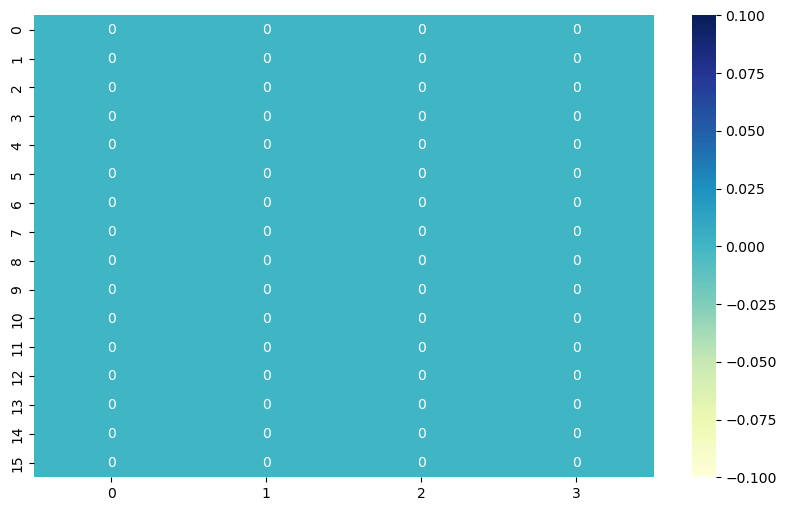

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(Q_table, annot=True,cmap='YlGnBu')

# Taxi Driver

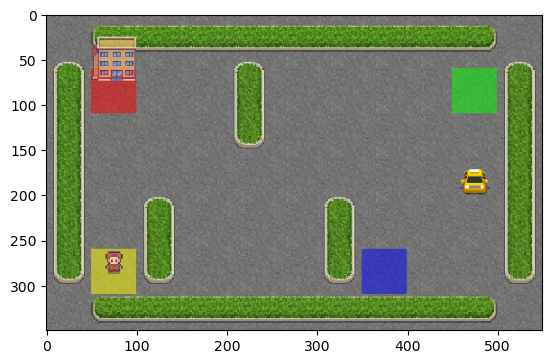

In [26]:
env = gym.make("Taxi-v3", render_mode='rgb_array')
state = env.reset()
img = env.render()
plt.imshow(img)

In [28]:
import numpy as np
import gymnasium as gym

# Create the Taxi environment
env = gym.make("Taxi-v3")
q_table = np.zeros([env.observation_space.n, env.action_space.n])
alpha = 0.8
gamma = 0.9
epsilon = 0.1

for episode in range(1000):
    state, info = env.reset()  # Gymnasium reset returns (obs, info)
    done = False
    
    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # Explore
        else:
            action = np.argmax(q_table[state])  # Exploit

        # Gymnasium step returns: obs, reward, terminated, truncated, info
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        q_table[state, action] += alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state

print("Trained Q-table for Taxi:\n", q_table)


Trained Q-table for Taxi:
 [[  0.           0.           0.           0.           0.
    0.        ]
 [ -4.90079452  -0.62313078  -2.95522591  -4.86781127   1.62261467
  -10.70592   ]
 [  2.65216524   5.86733756   4.17471117   4.07274705   7.7147
   -4.045416  ]
 ...
 [ -3.40918477   6.10032794  -3.52380764  -3.73248795  -8.
   -8.        ]
 [ -4.86781127  -4.82602185  -4.86781127   2.58522169  -8.
   -8.        ]
 [ -0.8         -1.536       11.28        17.           0.
    2.58392064]]


In [29]:
np.save('taxi.npy',q_table)

<Axes: >

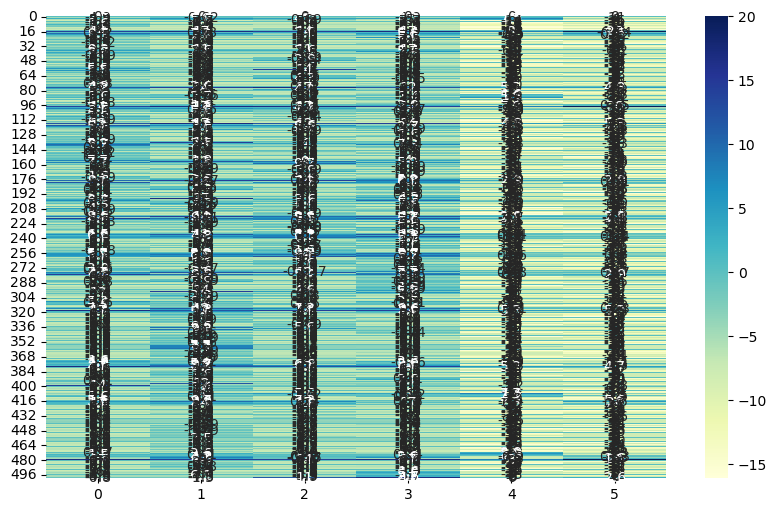

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(q_table, annot=True,cmap='YlGnBu')

In [34]:
import gymnasium as gym
import numpy as np
import random
import tensorflow as tf
from tensorflow import keras
from collections import deque

# Define the neural network
def build_model(state_size, action_size):
    model = keras.Sequential()
    model.add(keras.layers.Dense(24, input_dim=state_size, activation='relu'))
    model.add(keras.layers.Dense(24, activation='relu'))
    model.add(keras.layers.Dense(action_size, activation='linear'))
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=0.001))
    return model

# Initialize environment and parameters
env = gym.make('FrozenLake-v1', is_slippery=False)
state_size = env.observation_space.n
action_size = env.action_space.n

# Hyperparameters
num_episodes = 1000
gamma = 0.95  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
batch_size = 64
memory = deque(maxlen=2000)

# Build the model
model = build_model(state_size, action_size)
for episode in range(num_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # Explore
        else:
            state_tensor = np.identity(state_size)[state].reshape(1, state_size)
            action = np.argmax(model.predict(state_tensor, verbose=0)[0])  # Exploit

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # Store the experience in memory
        memory.append((state, action, reward, next_state, done))
        state = next_state
        total_reward += reward
        # Train the model if there are enough experiences
        if len(memory) > batch_size:
            minibatch = random.sample(memory, batch_size)
            for m_state, m_action, m_reward, m_next_state, m_done in minibatch:
                target = m_reward
                if not m_done:
                    next_state_tensor = np.identity(state_size)[m_next_state].reshape(1, state_size)
                    target += gamma * np.max(model.predict(next_state_tensor, verbose=0)[0])

                target_f = model.predict(np.identity(state_size)[m_state].reshape(1, state_size), verbose=0)
                target_f[0][m_action] = target

                model.fit(np.identity(state_size)[m_state].reshape(1, state_size), target_f, epochs=1, verbose=0)

    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    print(f"Episode {episode+1}/{num_episodes}, Total Reward: {total_reward}, Epsilon: {epsilon:.2f}")

# Close the environment
env.close()

Episode 1/1000, Total Reward: 0, Epsilon: 0.99
Episode 2/1000, Total Reward: 0, Epsilon: 0.99
Episode 3/1000, Total Reward: 0, Epsilon: 0.99
Episode 4/1000, Total Reward: 0, Epsilon: 0.98
Episode 5/1000, Total Reward: 0, Epsilon: 0.98
Episode 6/1000, Total Reward: 0, Epsilon: 0.97
Episode 7/1000, Total Reward: 0, Epsilon: 0.97
Episode 8/1000, Total Reward: 0, Epsilon: 0.96
Episode 9/1000, Total Reward: 0, Epsilon: 0.96
Episode 10/1000, Total Reward: 0, Epsilon: 0.95
Episode 11/1000, Total Reward: 0, Epsilon: 0.95
Episode 12/1000, Total Reward: 1, Epsilon: 0.94
Episode 13/1000, Total Reward: 0, Epsilon: 0.94
Episode 14/1000, Total Reward: 0, Epsilon: 0.93
Episode 15/1000, Total Reward: 0, Epsilon: 0.93
Episode 16/1000, Total Reward: 0, Epsilon: 0.92
Episode 17/1000, Total Reward: 0, Epsilon: 0.92
Episode 18/1000, Total Reward: 0, Epsilon: 0.91
Episode 19/1000, Total Reward: 0, Epsilon: 0.91
Episode 20/1000, Total Reward: 0, Epsilon: 0.90
Episode 21/1000, Total Reward: 0, Epsilon: 0.90
E

KeyboardInterrupt: 